# 🎨 Color Space Analysis
### Developer: Siew Feng

This notebook demonstrates exploratory work on analyzing mango ripeness using different color spaces.

### 1. Configuration

In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import joblib

# --- Paths ---
IMAGE_ROOT = "../cleaned_data"          # folder containing train/test subfolders
OUTPUT_DIR = "../output/color_based"    # where to save feature CSVs
DATASETS = ["train", "test"]
CLASSES = ["overripe", "fully_ripe", "unripe"]

# --- Color spaces and channel names ---
COLOR_SPACES = {
    "RGB":   {"cv_func": cv2.COLOR_BGR2RGB,   "channels": ["R", "G", "B"]},
    "HSV":   {"cv_func": cv2.COLOR_BGR2HSV,   "channels": ["H", "S", "V"]},
    "LAB":   {"cv_func": cv2.COLOR_BGR2LAB,   "channels": ["L", "A", "B"]},
    "YCbCr": {"cv_func": cv2.COLOR_BGR2YCrCb, "channels": ["Y", "Cb", "Cr"]},
    "HLS":   {"cv_func": cv2.COLOR_BGR2HLS,   "channels": ["H", "L", "S"]}
}

# --- Augmentation settings ---
AUGMENT = True
AUG_COUNT = 4               # number of augmented versions per original image
AUG_ROTATION_RANGE = 15     # degrees
AUG_BRIGHTNESS_RANGE = 0.2  # ±20%
AUG_CONTRAST_RANGE = 0.2

### 2. Utility Functions

In [2]:
def convert_color_spaces(bgr_image):
    """Convert BGR image to all defined color spaces."""
    results = {}
    for name, spec in COLOR_SPACES.items():
        results[name] = cv2.cvtColor(bgr_image, spec["cv_func"])
    return results

def extract_channel_statistics(channel, mask, prefix):
    """Extract statistics from a single channel masked area."""
    pixels = channel[mask > 0]
    if len(pixels) == 0:
        return {}
    return {
        f"{prefix}_Mean":   np.mean(pixels),
        f"{prefix}_Std":    np.std(pixels),
        f"{prefix}_Min":    np.min(pixels),
        f"{prefix}_Max":    np.max(pixels),
        f"{prefix}_Median": np.median(pixels),
        f"{prefix}_Q25":    np.percentile(pixels, 25),
        f"{prefix}_Q75":    np.percentile(pixels, 75)
    }

def extract_features(image, mask, color_space_name, channel_names):
    """Extract all channel statistics for a color space."""
    channels = cv2.split(image)
    features = {}
    for ch, name in zip(channels, channel_names):
        prefix = f"{color_space_name}_{name}"
        features.update(extract_channel_statistics(ch, mask, prefix))
    return features

def create_mask(bgr_image, threshold=50):
    """Create a binary mask for the mango region (simple threshold)."""
    gray = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2GRAY)
    mask = (gray > threshold).astype(np.uint8) * 255
    return mask

# Augmentation functions
def augment_image(image):
    """
    Generate augmented versions of an image.
    Returns list of augmented images (including original).
    """
    augmented = [image.copy()]
    h, w = image.shape[:2]
    center = (w//2, h//2)

    # Rotation
    for angle in np.random.uniform(-AUG_ROTATION_RANGE, AUG_ROTATION_RANGE, AUG_COUNT//2):
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(image, M, (w, h))
        augmented.append(rotated)

    # Horizontal flip
    flipped = cv2.flip(image, 1)
    augmented.append(flipped)

    # Brightness/Contrast adjustments
    for _ in range(AUG_COUNT//2):
        alpha = 1 + np.random.uniform(-AUG_CONTRAST_RANGE, AUG_CONTRAST_RANGE)
        beta = np.random.uniform(-AUG_BRIGHTNESS_RANGE*255, AUG_BRIGHTNESS_RANGE*255)
        adjusted = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
        augmented.append(adjusted)

    # Shuffle and limit to AUG_COUNT+1 (including original)
    np.random.shuffle(augmented)
    return augmented[:AUG_COUNT+1]

def process_image_for_features(bgr_image, mask, color_space_name, channel_names):
    """Convert image to a color space and extract features."""
    color_spaces = convert_color_spaces(bgr_image)
    img = color_spaces[color_space_name]
    features = extract_features(img, mask, color_space_name, channel_names)
    return features

def build_dataset(dataset_type, augment=True):
    """
    Build feature DataFrames for all color spaces for a given dataset (train/test).
    If augment=True, generate augmented versions for train set only.
    """
    # Initialize dict to store list of feature dicts per color space
    all_features = {name: [] for name in COLOR_SPACES}

    for cls in CLASSES:
        img_paths = glob.glob(os.path.join(IMAGE_ROOT, dataset_type, cls, "*.jpg"))
        print(f"Processing {dataset_type}/{cls}: {len(img_paths)} images")
        for path in tqdm(img_paths):
            img_name = os.path.basename(path)
            bgr = cv2.imread(path)
            if bgr is None:
                continue
            mask = create_mask(bgr)

            # Determine if we augment (only for train)
            do_augment = augment and (dataset_type == "train")
            images_to_process = [bgr]
            if do_augment:
                images_to_process = augment_image(bgr)

            for img_variant in images_to_process:
                for space_name, spec in COLOR_SPACES.items():
                    feats = process_image_for_features(
                        img_variant, mask, space_name, spec["channels"]
                    )
                    feats["Image_Name"] = img_name
                    feats["Label"] = cls
                    all_features[space_name].append(feats)

    # Convert to DataFrames
    dataframes = {}
    for space_name, feat_list in all_features.items():
        df = pd.DataFrame(feat_list)
        dataframes[space_name] = df

    return dataframes

### 3. Color Space Conversion Example

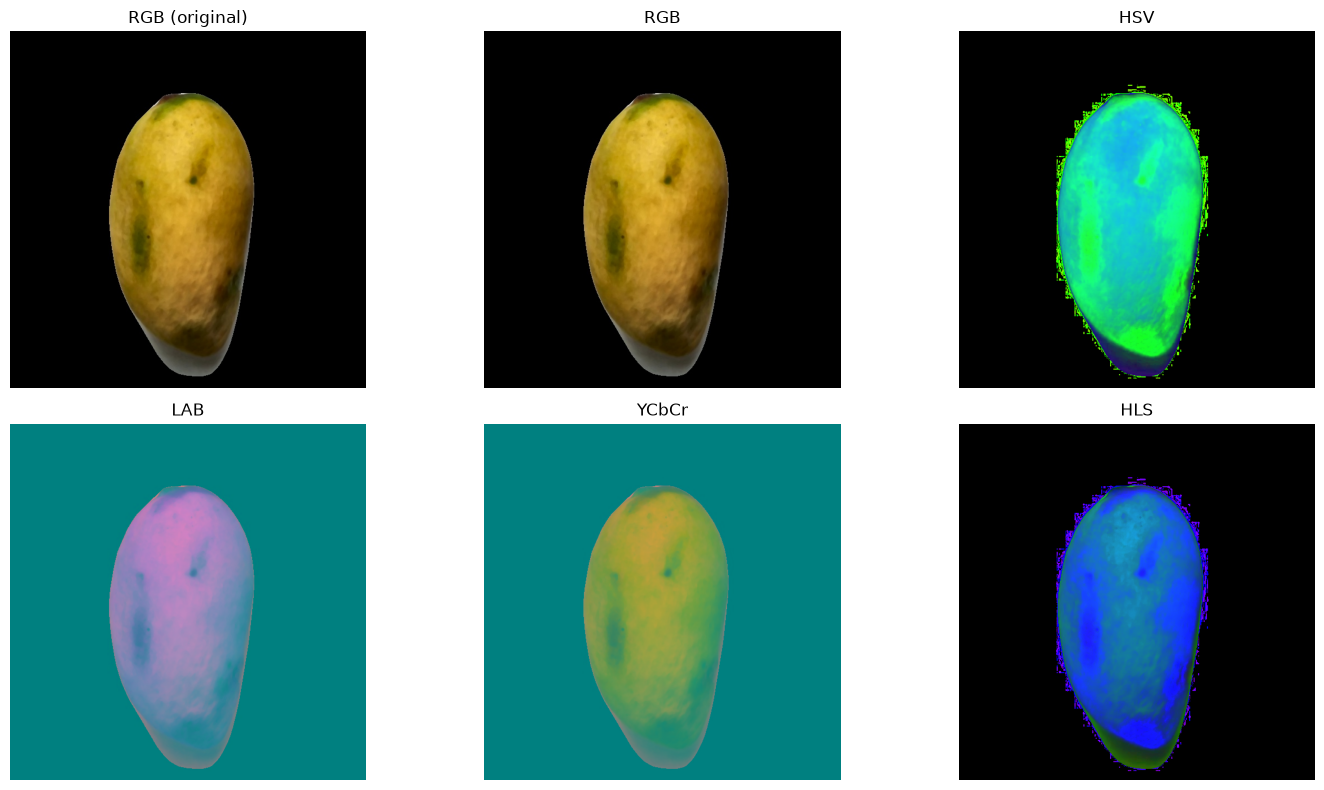

In [3]:
# Load a sample image for demonstration
sample_path = glob.glob(os.path.join(IMAGE_ROOT, "train", "fully_ripe", "*.jpg"))[0]
sample_bgr = cv2.imread(sample_path)
sample_rgb = cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2RGB)
color_spaces_sample = convert_color_spaces(sample_bgr)

# Plot
plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 1)
plt.imshow(sample_rgb)
plt.title("RGB (original)")
plt.axis("off")

for i, (name, img) in enumerate(color_spaces_sample.items(), start=2):
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 4. Data Augmentation Example

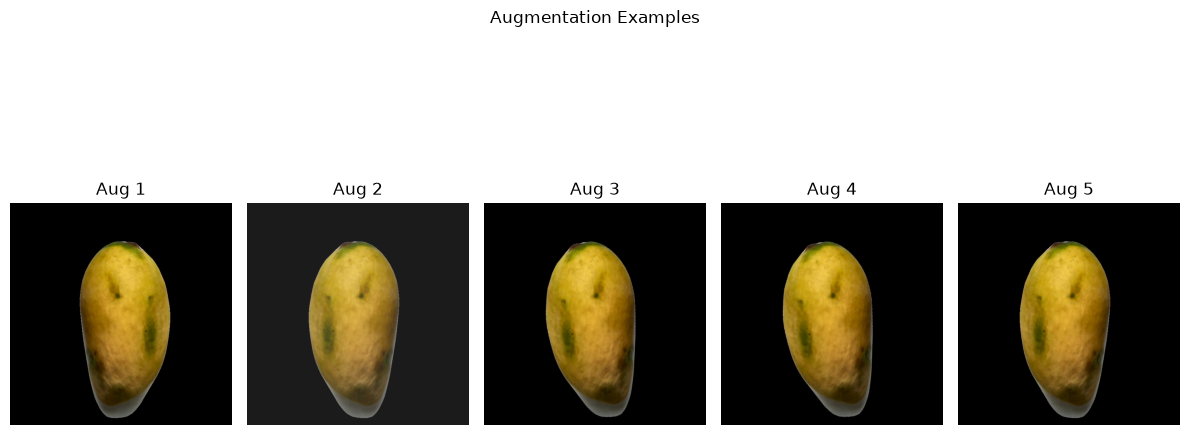

In [4]:
# Show original and augmented versions of a sample image
sample_img = cv2.imread(sample_path)
aug_versions = augment_image(sample_img)

plt.figure(figsize=(12, 6))
for i, aug in enumerate(aug_versions[:5]):  # show up to 5
    plt.subplot(1, 5, i+1)
    plt.imshow(cv2.cvtColor(aug, cv2.COLOR_BGR2RGB))
    plt.title(f"Aug {i+1}")
    plt.axis("off")
plt.suptitle("Augmentation Examples")
plt.tight_layout()
plt.show() 

### 5. Feature Extraction

In [5]:
# Build train and test datasets
print("Building train dataset...")
train_dfs = build_dataset("train", augment=AUGMENT)
print("Building test dataset...")
test_dfs = build_dataset("test", augment=False)   # no augmentation on test

# Save feature CSVs (optional)
os.makedirs(OUTPUT_DIR, exist_ok=True)
for ds_name, dfs in [("train", train_dfs), ("test", test_dfs)]:
    ds_dir = os.path.join(OUTPUT_DIR, ds_name)
    os.makedirs(ds_dir, exist_ok=True)
    for space_name, df in dfs.items():
        out_path = os.path.join(ds_dir, f"{space_name}_features.csv")
        df.to_csv(out_path, index=False)
        print(f"Saved {out_path}")

Building train dataset...
Processing train/overripe: 192 images


100%|██████████| 192/192 [01:27<00:00,  2.19it/s]


Processing train/fully_ripe: 189 images


100%|██████████| 189/189 [01:10<00:00,  2.67it/s]


Processing train/unripe: 190 images


...

Processing test/fully_ripe: 48 images


100%|██████████| 48/48 [00:04<00:00, 11.38it/s]


Processing test/unripe: 48 images


100%|██████████| 48/48 [00:04<00:00, 10.45it/s]


Saved ../output/color_based\train\RGB_features.csv
Saved ../output/color_based\train\HSV_features.csv
Saved ../output/color_based\train\LAB_features.csv
Saved ../output/color_based\train\YCbCr_features.csv
Saved ../output/color_based\train\HLS_features.csv
Saved ../output/color_based\test\RGB_features.csv
Saved ../output/color_based\test\HSV_features.csv
Saved ../output/color_based\test\LAB_features.csv
Saved ../output/color_based\test\YCbCr_features.csv
Saved ../output/color_based\test\HLS_features.csv


### 6. Train SVM for Each Color Space

In [6]:
train_dfs = {}
test_dfs = {}

for space_name in COLOR_SPACES:
    train_path = os.path.join(OUTPUT_DIR, "train", f"{space_name}_features.csv")
    test_path  = os.path.join(OUTPUT_DIR, "test", f"{space_name}_features.csv")
    train_dfs[space_name] = pd.read_csv(train_path)
    test_dfs[space_name]  = pd.read_csv(test_path)

# We'll store results for each color space
results = {}

# Define feature columns (we'll use mean, std, median from each channel)
def get_feature_columns(space_name, channels):
    # We'll use Mean, Std, Median for each channel
    cols = []
    for ch in channels:
        cols.extend([f"{space_name}_{ch}_Mean", f"{space_name}_{ch}_Std", f"{space_name}_{ch}_Median"])
    return cols

for space_name in COLOR_SPACES:
    print(f"\n=== Training for {space_name} ===")
    train_df = train_dfs[space_name]
    test_df = test_dfs[space_name]

    feature_cols = get_feature_columns(space_name, COLOR_SPACES[space_name]["channels"])
    X_train = train_df[feature_cols]
    y_train = train_df["Label"]
    X_test = test_df[feature_cols]
    y_test = test_df["Label"]

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train SVM
    model = SVC(kernel="rbf", random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[space_name] = {
        "model": model,
        "scaler": scaler,
        "accuracy": acc,
        "report": report,
        "y_true": y_test,
        "y_pred": y_pred,
        "feature_cols": feature_cols
    }

    print(f"Accuracy: {acc:.2%}")
    print(classification_report(y_test, y_pred))


=== Training for RGB ===
Accuracy: 93.06%
              precision    recall  f1-score   support

  fully_ripe       0.93      0.85      0.89        48
    overripe       0.87      0.94      0.90        48
      unripe       1.00      1.00      1.00        48

    accuracy                           0.93       144
   macro avg       0.93      0.93      0.93       144
weighted avg       0.93      0.93      0.93       144


=== Training for HSV ===
Accuracy: 97.22%
              precision    recall  f1-score   support

  fully_ripe       0.94      0.98      0.96        48
    overripe       0.98      0.94      0.96        48
      unripe       1.00      1.00      1.00        48

    accuracy                           0.97       144
   macro avg       0.97      0.97      0.97       144
weighted avg       0.97      0.97      0.97       144


=== Training for LAB ===
Accuracy: 100.00%
              precision    recall  f1-score   support

  fully_ripe       1.00      1.00      1.00        48

### 7. Confusion Matrices for All Color Spaces

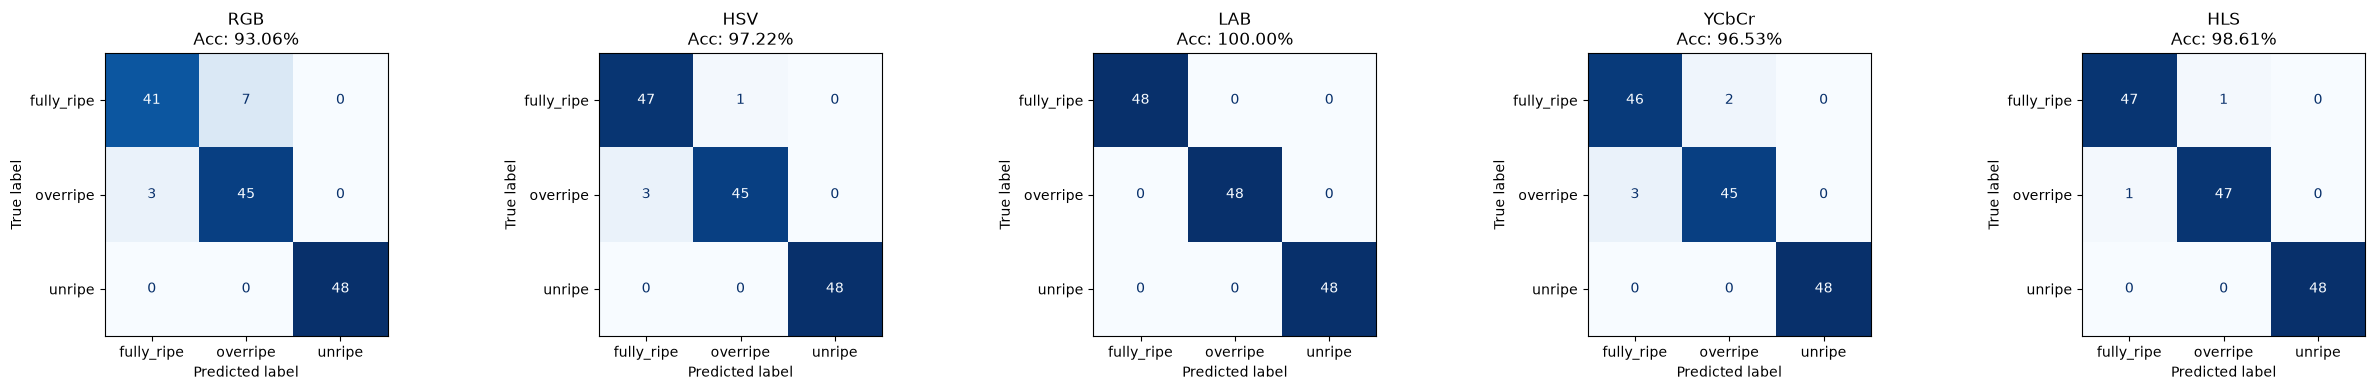

In [7]:
fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 4))
if len(results) == 1:
    axes = [axes]
for ax, (space_name, res) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        res["y_true"], res["y_pred"],
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(f"{space_name}\nAcc: {res['accuracy']:.2%}")
plt.tight_layout()
plt.show()

### 8. Classification Report Summary

In [8]:
# Display a combined table
summary = []
for space_name, res in results.items():
    report = res["report"]
    row = {
        "Color Space": space_name,
        "Accuracy": res["accuracy"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    }
    # Add per-class F1
    for cls in CLASSES:
        row[f"F1-{cls}"] = report[cls]["f1-score"]
    summary.append(row)

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

Color Space  Accuracy  Macro F1  Weighted F1  F1-overripe  F1-fully_ripe  F1-unripe
        RGB  0.930556  0.930435     0.930435     0.900000       0.891304        1.0
        HSV  0.972222  0.972210     0.972210     0.957447       0.959184        1.0
        LAB  1.000000  1.000000     1.000000     1.000000       1.000000        1.0
      YCbCr  0.965278  0.965274     0.965274     0.947368       0.948454        1.0
        HLS  0.986111  0.986111     0.986111     0.979167       0.979167        1.0


### 9. Save Models and Scalers

In [9]:
models_dir = os.path.join(OUTPUT_DIR, "models")
os.makedirs(models_dir, exist_ok=True)

for space_name, res in results.items():
    model_path = os.path.join(models_dir, f"{space_name}_model.pkl")
    scaler_path = os.path.join(models_dir, f"{space_name}_scaler.pkl")
    
    joblib.dump(res["model"], model_path)
    joblib.dump(res["scaler"], scaler_path)
    
    print(f"Saved model and scaler for {space_name}")

Saved model and scaler for RGB
Saved model and scaler for HSV
Saved model and scaler for LAB
Saved model and scaler for YCbCr
Saved model and scaler for HLS


### 10.  Example Prediction on a New Image

Predictions per color space:
RGB: unripe
HSV: unripe
LAB: unripe
YCbCr: unripe
HLS: unripe


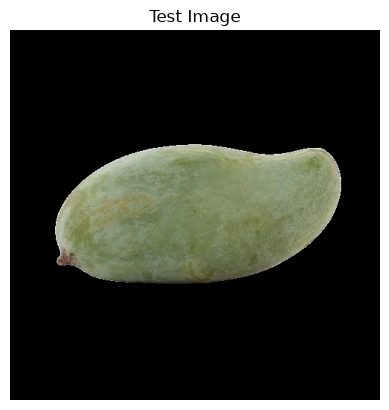

In [10]:
# Example: predict ripeness for a new image using all models
def predict_ripeness(image_path, models_dict):
    bgr = cv2.imread(image_path)
    if bgr is None:
        print("Error: could not load image")
        return
    mask = create_mask(bgr)
    color_spaces_img = convert_color_spaces(bgr)

    predictions = {}
    for space_name, res in results.items():
        spec = COLOR_SPACES[space_name]
        img = color_spaces_img[space_name]
        feats = extract_features(img, mask, space_name, spec["channels"])
        # Build feature vector
        feature_cols = res["feature_cols"]
        X = pd.DataFrame([{col: feats[col] for col in feature_cols}])
        X_scaled = res["scaler"].transform(X)
        pred = res["model"].predict(X_scaled)[0]
        predictions[space_name] = pred

    return predictions

# Test on a sample test image
# test_img_path = glob.glob(os.path.join(IMAGE_ROOT, "test", "fully_ripe", "*.jpg"))[0]
test_img_path = r"..\test_images\unripe_1.jpg"
preds = predict_ripeness(test_img_path, results)
print("Predictions per color space:")
for space, pred in preds.items():
    print(f"{space}: {pred}")

# Show the image
test_bgr = cv2.imread(test_img_path)
plt.imshow(cv2.cvtColor(test_bgr, cv2.COLOR_BGR2RGB))
plt.title("Test Image")
plt.axis("off")
plt.show()